In [1]:
import polars as pl
import matplotlib.pyplot as plt
from pathlib import Path
import numpy.random as npr
import numpy as np
import seaborn as sns

In [2]:
input_columns = [
    # Alzheimer's Disease
    "NACCALZP",
    # Lewy Body Disease
    "NACCLBDP",
    # Vascular Dementia related
    "CVDIF",
    "VASCIF",
    "VASCPSIF",
    "STROKIF",
    # Prion Disease
    "PRIONIF",
    # Frontotemporal Dementia related
    "FTLDNOIF",
    "FTDIF",
    "FTLDMOIF",
    "PPAPHIF",
    "PSPIF",
    "CORTIF",
    # Normal Pressure Hydrocephalus
    "HYCEPHIF",
    # Systemic and External Factors
    "OTHCOGIF",
    "HIVIF",
    "ALCDEMIF",
    "IMPSUBIF",
    "DYSILLIF",
    "MEDSIF",
    "DELIRIF",
    # Psychiatric Conditions
    "DEPIF",
    "BIPOLDIF",
    "SCHIZOIF",
    "ANXIETIF",
    "PTSDDXIF",
    "OTHPSYIF",
    # Traumatic Brain Injury
    "BRNINJIF",
    # Other Dementia Etiologies
    "MSAIF",
    "ESSTREIF",
    "DOWNSIF",
    "HUNTIF",
    "EPILEPIF",
    "NEOPIF",
    "DEMUNIF",
    "COGOTHIF",
    "COGOTH2F",
    "COGOTH3F",
]

input_to_etiology = {
    # Alzheimer's Disease
    "NACCALZP":"AD",
    # Lewy Body Disease
    "NACCLBDP":"LBD",
    # Vascular Dementia related
    "CVDIF":"VD",
    "VASCIF":"VD",
    "VASCPSIF":"VD",
    "STROKIF":"VD",
    # Prion Disease
    "PRIONIF":"ODE",
    # Frontotemporal Dementia related
    "FTLDNOIF":"FTLD",
    "FTDIF":"FTLD",
    "FTLDMOIF":"FTLD",
    "PPAPHIF":"FTLD",
    "PSPIF":"FTLD",
    "CORTIF":"FTLD",
    # Normal Pressure Hydrocephalus
    "HYCEPHIF":"ODE",
    # Systemic and External Factors
    "OTHCOGIF":"ODE",
    "HIVIF":"ODE",
    "ALCDEMIF":"ODE",
    "IMPSUBIF":"ODE",
    "DYSILLIF":"ODE",
    "MEDSIF":"ODE",
    "DELIRIF":"ODE",
    # Psychiatric Conditions
    "DEPIF":"PSY",
    "BIPOLDIF":"PSY",
    "SCHIZOIF":"PSY",
    "ANXIETIF":"PSY",
    "PTSDDXIF":"PSY",
    "OTHPSYIF":"PSY",
    # Traumatic Brain Injury
    "BRNINJIF":"ODE",
    # Other Dementia Etiologies
    "MSAIF":"ODE",
    "ESSTREIF":"ODE",
    "DOWNSIF":"ODE",
    "HUNTIF":"ODE",
    "EPILEPIF":"ODE",
    "NEOPIF":"ODE",
    "DEMUNIF":"ODE",
    "COGOTHIF":"ODE",
    "COGOTH2F":"ODE",
    "COGOTH3F":"ODE",
}

output_columns = [
    "NC",  # Normal Cognition (NACCUDSD == 1)
    "IMCI",  # Impaired, Not MCI (NACCUDSD == 2)
    "MCI",  # Mild Cognitive Impairment (NACCUDSD == 3)
    "DE",  # Dementia (NACCUDSD == 4)
    "AD",  # Alzheimer's Disease
    "LBD",  # Lewy Body Disease
    "VD",  # Vascular Dementia
    # "PRD",  # Prion Disease (CJD, other)
    "FTLD",  # Frontotemporal Dementia (including CBD, PSP, with/without ALS)
    # "NPH",  # Normal Pressure Hydrocephalus
    "SEF",  # Systemic and External Factors (infectious, metabolic, substance abuse, etc.)
    "PSY",  # Psychiatric Conditions (depression, bipolar, schizophrenia, anxiety, PTSD)
    # "TBI",  # Traumatic Brain Injury
    "ODE",  # Other Dementia Etiology
]

diagnoses = ["NC", "IMCI", "MCI", "DE"]

etiologies = sorted(
    ["AD", "LBD", "VD", "FTLD", "SEF", "PSY", 
    # "PRD", 
    # "TBI", 
    # "NPH"
    "ODE", 
    ]
)

In [4]:
nacc_path = Path(
    "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/data/nacc/training_data/testing_data_grpo/test_summary.csv"
)

# nacc_path_train = Path(
    # "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/data/nacc/training_data/training_data_grpo_modified_cog_np/subset/all_train_inc_oversample_sub_deduplicated_merged.csv"
# )

nacc = pl.read_csv(nacc_path, infer_schema_length=None).with_columns(
    pl.col(input_columns)
    .fill_null(-4)
    .cast(pl.Int64)  # .replace_strict({1:1,2:2},default=0)
# ).rename({'ID':'NACCID'})
)

In [6]:
# nacc_multilabel.select((pl.col(etiologies) > 0).cast(pl.Int8)).sum()

In [7]:
counts = (
    pl.concat(
        [
            nacc.select(pl.col(colname).value_counts())
            .unnest(colname)
            .sort(colname)
            .with_columns(
                pl.lit(colname).alias("variable"), pl.col(colname).cast(pl.Int32)
            )
            .pivot(on=colname, index="variable", values="count")
            for colname in input_columns
        ],
        how="diagonal",
    )
    .with_columns(
        pl.col("variable").replace_strict(input_to_etiology).alias("etiology")
    )
    .fill_null(0)
)


In [8]:
with pl.Config(tbl_rows=100):
    display(
        counts.select("variable", "etiology", "1", "2", (pl.col("1") + pl.col("2")).sum().over('etiology').alias('total'))
    )

variable,etiology,1,2,total
str,str,u32,u32,u32
"""NACCALZP""","""AD""",13099,425,13524
"""NACCLBDP""","""LBD""",595,530,1125
"""CVDIF""","""VD""",194,574,1823
"""VASCIF""","""VD""",109,161,1823
"""VASCPSIF""","""VD""",70,259,1823
"""STROKIF""","""VD""",30,426,1823
"""PRIONIF""","""ODE""",82,3,2877
"""FTLDNOIF""","""FTLD""",325,33,1606
"""FTDIF""","""FTLD""",408,109,1606


In [9]:
def labels_conversion(df: pl.DataFrame) -> pl.DataFrame:
    """
    Convert diagnostic labels based on NACCUDSD and various condition indicators.

    Args:
        df: Input DataFrame with diagnostic columns

    Returns:
        DataFrame with additional binary label columns (NC, IMCI, MCI, DE, AD, LBD, VD, etc.)
    """

    def is_primary_or_contributing(col_name: str) -> pl.Expr:
        # Helper function to check if value etiology is primary (1) or contributing (2)
        # in etiology variables such as NACCALZP
        # 1 = primary
        # 2 = contributing
        return (
            pl.when(pl.col(col_name).is_in([1, 2])).then(pl.col(col_name)).otherwise(0)
        )

    # We only assign etiological labels to cases with at least MCI
    abnormal_cognition = pl.col("NACCUDSD").is_in([3, 4]).cast(pl.Int8)

    return (
        df.with_columns(
            [
                # Diagnosis
                (pl.col("NACCUDSD") == 1).cast(pl.Int8).alias("NC"),
                (pl.col("NACCUDSD") == 2).cast(pl.Int8).alias("IMCI"), # we dropped all of these
                (pl.col("NACCUDSD") == 3).cast(pl.Int8).alias("MCI"),
                (pl.col("NACCUDSD") == 4).cast(pl.Int8).alias("DE"),
                # Alzheimer's Disease
                (is_primary_or_contributing("NACCALZP") * abnormal_cognition)
                .cast(pl.Int8)
                .alias("AD"),
                # Lewy Body Disease
                (is_primary_or_contributing("NACCLBDP") * abnormal_cognition)
                .cast(pl.Int8)
                .alias("LBD"),
                # Vascular Dementia
                pl.when(
                    pl.any_horizontal(
                        pl.col("CVDIF", "VASCIF", "VASCPSIF", "STROKIF") == 1
                    )
                    & (abnormal_cognition == 1)
                )
                .then(1)
                .when(
                    pl.any_horizontal(
                        pl.col("CVDIF", "VASCIF", "VASCPSIF", "STROKIF") == 2
                    )
                    & (abnormal_cognition == 1)
                )
                .then(2)
                .otherwise(0)
                .cast(pl.Int8)
                .alias("VD"),
                # # Prion Disease
                # (is_primary_or_contributing("PRIONIF") & abnormal_cognition)
                # .cast(pl.Int8)
                # .alias("PRD"),
                # Frontotemporal Dementia
                pl.when(
                    (
                        pl.any_horizontal(
                            pl.col(
                                "FTLDNOIF",
                                "FTDIF",
                                "FTLDMOIF",
                                "PPAPHIF",
                                "PSPIF",
                                "CORTIF",
                            )
                            == 1
                        )
                    )
                    & (abnormal_cognition == 1)
                )
                .then(1)
                .when(
                    (
                        pl.any_horizontal(
                            pl.col(
                                "FTLDNOIF",
                                "FTDIF",
                                "FTLDMOIF",
                                "PPAPHIF",
                                "PSPIF",
                                "CORTIF",
                            )
                            == 2
                        )
                    )
                    & (abnormal_cognition == 1)
                )
                .then(2)
                .otherwise(0)
                .cast(pl.Int8)
                .alias("FTLD"),
                # # Normal Pressure Hydrocephalus
                # (is_primary_or_contributing("HYCEPHIF") & abnormal_cognition)
                # .cast(pl.Int8)
                # .alias("NPH"),
                # Systemic and External Factors
                pl.when(
                    (
                        pl.any_horizontal(
                            pl.col(
                                "OTHCOGIF",
                                "HIVIF",
                                "ALCDEMIF",
                                "IMPSUBIF",
                                "DYSILLIF",
                                "MEDSIF",
                                "DELIRIF",
                            )
                            == 1
                        )
                    )
                    & (abnormal_cognition == 1)
                )
                .then(1)
                .when(
                    (
                        pl.any_horizontal(
                            pl.col(
                                "OTHCOGIF",
                                "HIVIF",
                                "ALCDEMIF",
                                "IMPSUBIF",
                                "DYSILLIF",
                                "MEDSIF",
                                "DELIRIF",
                            )
                            == 2
                        )
                    )
                    & (abnormal_cognition == 1)
                )
                .then(2)
                .otherwise(0)
                .cast(pl.Int8)
                .alias("SEF"),
                # Psychiatric Conditions
                pl.when(
                    (
                        pl.any_horizontal(
                            pl.col(
                                "DEPIF",
                                "BIPOLDIF",
                                "SCHIZOIF",
                                "ANXIETIF",
                                "PTSDDXIF",
                                "OTHPSYIF",
                            )
                            == 1
                        )
                    )
                    & (abnormal_cognition == 1)
                )
                .then(1)
                .when(
                    (
                        pl.any_horizontal(
                            pl.col(
                                "DEPIF",
                                "BIPOLDIF",
                                "SCHIZOIF",
                                "ANXIETIF",
                                "PTSDDXIF",
                                "OTHPSYIF",
                            )
                            == 2
                        )
                    )
                    & (abnormal_cognition == 1)
                )
                .then(2)
                .otherwise(0)
                .cast(pl.Int8)
                .alias("PSY"),
                # Traumatic Brain Injury
                # (is_primary_or_contributing("BRNINJIF") * abnormal_cognition)
                # .cast(pl.Int8)
                # .alias("TBI"),
            ]
        )
        .with_columns(
            [
                # Other Dementia Etiology - requires checking if no primary diagnosis was made
                # Calculate flag: any of the specific diagnoses
                (
                    pl.any_horizontal(
                        pl.col(
                            [etiology for etiology in etiologies if etiology != "ODE"]
                        )
                        == 1
                    )
                ).alias("has_primary_dx")
            ]
        )
        .with_columns(
            [
                # ODE is primary if dementia with no primary diagnosis OR with other specified conditions as primary
                pl.when(
                    (
                        (abnormal_cognition == 1)
                        & (
                            ~pl.col("has_primary_dx")
                            | (
                                pl.any_horizontal(
                                    pl.col(
                                        "MSAIF",
                                        "ESSTREIF",
                                        "DOWNSIF",
                                        "HUNTIF",
                                        "EPILEPIF",
                                        "NEOPIF",
                                        "BRNINJIF",
                                        "HYCEPHIF",
                                        "PRIONIF",
                                        "DEMUNIF",
                                    )
                                    == 1
                                )
                            )
                        )
                    )
                )
                .then(1)
                .when(
                    (
                        (
                            pl.any_horizontal(
                                pl.col(
                                    "MSAIF",
                                    "ESSTREIF",
                                    "DOWNSIF",
                                    "HUNTIF",
                                    "EPILEPIF",
                                    "NEOPIF",
                                    "BRNINJIF",
                                    "HYCEPHIF",
                                    "PRIONIF",
                                    "DEMUNIF",
                                )
                                == 2
                            )
                        )
                        & (abnormal_cognition == 1)
                    )
                )
                .then(2)
                .otherwise(0)
                .cast(pl.Int8)
                .alias("ODE"),

               abnormal_cognition.cast(pl.Boolean).alias('impaired') 
            ]
        )
    )

In [10]:
nacc_multilabel = labels_conversion(nacc)

In [11]:
nacc_multilabel.select(etiologies).null_count()

AD,FTLD,LBD,ODE,PSY,SEF,VD
u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0


In [12]:
nacc_multilabel.select(
    'NACCID',
    pl.col(diagnoses),
    'impaired'
)

NACCID,NC,IMCI,MCI,DE,impaired
str,i8,i8,i8,i8,bool
"""NACC282885""",1,0,0,0,false
"""NACC837281""",0,0,0,1,true
"""NACC355961""",0,0,1,0,true
"""NACC385116""",1,0,0,0,false
"""NACC260495""",0,0,0,1,true
…,…,…,…,…,…
"""NACC060902""",0,0,1,0,true
"""NACC241409""",1,0,0,0,false
"""NACC633787""",0,0,0,1,true


check that every impaired case has exactly one primary etiology

In [13]:
nacc_multilabel.filter(
    'impaired'
).select(
    'NACCID',
    pl.col(etiologies),
    pl.sum_horizontal((pl.col(etiologies) == 1).cast(pl.Int8)).alias('num_primary')
).sort('num_primary')

NACCID,AD,FTLD,LBD,ODE,PSY,SEF,VD,num_primary
str,i8,i8,i8,i8,i8,i8,i8,i8
"""NACC837281""",0,1,0,0,0,0,0,1
"""NACC355961""",1,0,0,0,0,0,0,1
"""NACC260495""",0,1,0,0,0,0,0,1
"""NACC030868""",1,0,0,0,0,0,2,1
"""NACC298932""",1,0,0,0,2,0,0,1
…,…,…,…,…,…,…,…,…
"""NACC077455""",1,0,0,0,0,0,0,1
"""NACC145214""",1,0,0,0,0,0,0,1
"""NACC060902""",0,0,0,1,2,0,0,1


In [14]:
# check that all the unimpaired cases have no primary or secondary etiology
nacc_multilabel.filter(
    ~pl.col('impaired')
).select(
    'NACCID',
    pl.col(etiologies),
    pl.sum_horizontal(pl.col(etiologies)).alias('num_etiologies')
).sort('num_etiologies')

NACCID,AD,FTLD,LBD,ODE,PSY,SEF,VD,num_etiologies
str,i8,i8,i8,i8,i8,i8,i8,i8
"""NACC282885""",0,0,0,0,0,0,0,0
"""NACC385116""",0,0,0,0,0,0,0,0
"""NACC995028""",0,0,0,0,0,0,0,0
"""NACC602773""",0,0,0,0,0,0,0,0
"""NACC441663""",0,0,0,0,0,0,0,0
…,…,…,…,…,…,…,…,…
"""NACC943707""",0,0,0,0,0,0,0,0
"""NACC718602""",0,0,0,0,0,0,0,0
"""NACC062838""",0,0,0,0,0,0,0,0


The following are cases with unknown primary etiology, we only have contributing 

In [15]:
nacc_minimal = nacc_multilabel.select(
    'NACCID',
    pl.col('NACCUDSD').replace_strict({1:"NC",3:"MCI",4:"DE"}).alias('diagnosis'),
    pl.col(etiologies)
)

In [16]:
nacc_minimal.filter(pl.col('diagnosis') != 'NC').with_columns(
    pl.concat_list(
        [
            pl.when(pl.col(col) > 0).then(pl.lit(col)) for col in etiologies
        ]
    ).list.drop_nulls().alias('etiologies')
)

NACCID,diagnosis,AD,FTLD,LBD,ODE,PSY,SEF,VD,etiologies
str,str,i8,i8,i8,i8,i8,i8,i8,list[str]
"""NACC837281""","""DE""",0,1,0,0,0,0,0,"[""FTLD""]"
"""NACC355961""","""MCI""",1,0,0,0,0,0,0,"[""AD""]"
"""NACC260495""","""DE""",0,1,0,0,0,0,0,"[""FTLD""]"
"""NACC030868""","""DE""",1,0,0,0,0,0,2,"[""AD"", ""VD""]"
"""NACC298932""","""MCI""",1,0,0,0,2,0,0,"[""AD"", ""PSY""]"
…,…,…,…,…,…,…,…,…,…
"""NACC077455""","""DE""",1,0,0,0,0,0,0,"[""AD""]"
"""NACC145214""","""DE""",1,0,0,0,0,0,0,"[""AD""]"
"""NACC060902""","""MCI""",0,0,0,1,2,0,0,"[""ODE"", ""PSY""]"


In [17]:
with pl.Config(tbl_rows=20):
    display(
        nacc_minimal.filter(pl.col("diagnosis") != "NC")
        .with_columns(
            pl.concat_list(
                [pl.when(pl.col(col) > 0).then(pl.lit(col)) for col in etiologies]
            )
            .list.drop_nulls()
            .alias("etiologies")
        )
        .select(pl.col("etiologies").value_counts())
        .unnest("etiologies")
        .sort("count", descending=True).head(20)
    )

etiologies,count
list[str],u32
"[""AD""]",9708
"[""AD"", ""PSY""]",1204
"[""ODE""]",1038
"[""FTLD""]",1000
"[""AD"", ""VD""]",897
"[""AD"", ""LBD""]",414
"[""LBD""]",401
"[""AD"", ""SEF""]",258
"[""VD""]",226


In [18]:
(
    nacc_minimal.select(
        pl.sum_horizontal(pl.col(etiologies) > 0).alias("num_etiologies").value_counts()
    )
    .unnest("num_etiologies")
    .sort("num_etiologies")
)

num_etiologies,count
u32,u32
0,13819
1,12703
2,3737
3,680
4,86
5,2
6,2


6% of cases have 3 or more etiologies at the same time

In [19]:
(
    nacc_minimal.filter(pl.col('diagnosis') !='NC').select(
        pl.sum_horizontal(pl.col(etiologies) > 0).alias("num_etiologies").value_counts()
    )
    .unnest("num_etiologies")
    .sort("num_etiologies")
    .with_columns(
        pl.col("num_etiologies")
        .cut([0, 1, 2], labels=["0", "1", "2", "3+"])
        .alias("binned_etiologies")
    )
    .group_by("binned_etiologies")
    .agg(pl.col('count').sum()).sort('binned_etiologies')
    .with_columns(
        (pl.col('count') /pl.col('count').sum()).round(3).alias('frac')
    )
)

binned_etiologies,count,frac
cat,u32,f64
"""1""",12703,0.738
"""2""",3737,0.217
"""3+""",770,0.045


In [20]:
nacc_minimal.with_columns(
    pl.sum_horizontal(pl.col(etiologies) > 0).alias("num_etiologies")
)

NACCID,diagnosis,AD,FTLD,LBD,ODE,PSY,SEF,VD,num_etiologies
str,str,i8,i8,i8,i8,i8,i8,i8,u32
"""NACC282885""","""NC""",0,0,0,0,0,0,0,0
"""NACC837281""","""DE""",0,1,0,0,0,0,0,1
"""NACC355961""","""MCI""",1,0,0,0,0,0,0,1
"""NACC385116""","""NC""",0,0,0,0,0,0,0,0
"""NACC260495""","""DE""",0,1,0,0,0,0,0,1
…,…,…,…,…,…,…,…,…,…
"""NACC060902""","""MCI""",0,0,0,1,2,0,0,2
"""NACC241409""","""NC""",0,0,0,0,0,0,0,0
"""NACC633787""","""DE""",0,1,0,0,0,0,0,1


In [21]:
(
    nacc_minimal.filter(pl.col("diagnosis") != "NC")
    .with_columns(
        pl.concat_list(
            [pl.when(pl.col(col) > 0).then(pl.lit(col)) for col in etiologies]
        )
        .list.drop_nulls()
        .alias("etiologies")
    )
)

NACCID,diagnosis,AD,FTLD,LBD,ODE,PSY,SEF,VD,etiologies
str,str,i8,i8,i8,i8,i8,i8,i8,list[str]
"""NACC837281""","""DE""",0,1,0,0,0,0,0,"[""FTLD""]"
"""NACC355961""","""MCI""",1,0,0,0,0,0,0,"[""AD""]"
"""NACC260495""","""DE""",0,1,0,0,0,0,0,"[""FTLD""]"
"""NACC030868""","""DE""",1,0,0,0,0,0,2,"[""AD"", ""VD""]"
"""NACC298932""","""MCI""",1,0,0,0,2,0,0,"[""AD"", ""PSY""]"
…,…,…,…,…,…,…,…,…,…
"""NACC077455""","""DE""",1,0,0,0,0,0,0,"[""AD""]"
"""NACC145214""","""DE""",1,0,0,0,0,0,0,"[""AD""]"
"""NACC060902""","""MCI""",0,0,0,1,2,0,0,"[""ODE"", ""PSY""]"


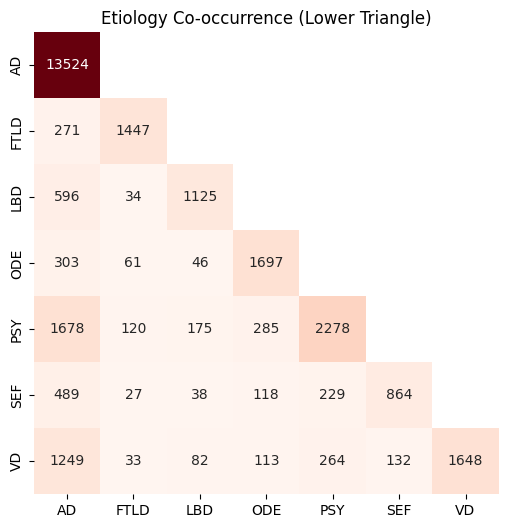

In [22]:
X = nacc_minimal.select((pl.col(etiologies) > 0).cast(pl.Int64)).to_numpy()

# co-occurrence matrix
co_occ = X.T @ X

mask = np.triu(np.ones_like(co_occ, dtype=bool),k=1)  # True for upper triangle

plt.figure(figsize=(6,6))
sns.heatmap(co_occ, mask=mask, xticklabels=etiologies, yticklabels=etiologies,
            annot=True, fmt="d", cmap="Reds", cbar=False)
plt.title("Etiology Co-occurrence (Lower Triangle)")
plt.show()

In [23]:
questions_multilabel = [
    "Based on the clinical details, determine the main causes of the patient's cognitive impairment, if applicable.",
    "Using the information provided, identify all the contributing causes of the patient's cognitive decline, if applicable.",
    "Determine all the etiologies underlying the patient's cognitive impairment based on the provided information, if applicable.",
    "Identify all the etiologes of the patient's cognitive impairment using the information provided, if applicable.",
    "Identify all the etiologic diagnoses of the patient using the information provided, if applicable.",
]

# options_multilabel = [
#     "Alzheimer's Disease",
#     "Lewy Body Disease (including Dementia with Lewy Bodies and Parkinson's disease).",
#     "Vascular Dementia.",
#     "Frontotemporal Dementia (FTLD. Including CBD, PSP, with/without ALS).",
#     "Systemic and External Factors (infectious, metabolic, substance abuse, etc.).",
#     "Psychiatric Conditions (depression, bipolar, schizophrenia, anxiety, PTSD).",
#     "Other Dementia Etiology, including MSA, Down's syndrome, Huntington's, Epilepsy, Neoplasm, and any etiology not appearing in another option.",
#     "Not applicable, no cognitive impairment.",
# ]

options_multilabel = [
    "Alzheimer's disease (AD)",
    "Lewy body disease (LBD)",
    "Frontotemporal lobar degeneration and its variants, including primary progressive aphasia, corticobasal degeneration and progressive supranuclear palsy, and with or without amyotrophic lateral sclerosis (FTLD)",
    "Vascular brain injury or vascular dementia including stroke (VD)",
    "Systemic and environmental factors including infectious diseases (HIV included), metabolic, substance abuse / alcohol, medications, systemic disease and delirium (SEF)",
    "Psychiatric conditions including schizophrenia, depression, bipolar disorder, anxiety and posttraumatic stress disorder (PSY)",
    "Other (Multiple system atrophy, Essential tremor, Down syndrome, Huntington's disease, Prion disease, Traumatic brain injury, Normal-pressure hydrocephalus, Epilepsy, CNS neoplasm, etc)",
    "Not applicable (no cognitive impairment)",
]

option_letters = ["A. ", "B. ", "C. ", "D. ", "E. ", "F. ", "G. ", "H. "]

In [24]:
def get_options():
    return '\n'.join(option_letters + npr.permutation(options_multilabel))

def get_question():
    return str(npr.choice(questions_multilabel))

In [25]:
get_options()

"A. Frontotemporal lobar degeneration and its variants, including primary progressive aphasia, corticobasal degeneration and progressive supranuclear palsy, and with or without amyotrophic lateral sclerosis (FTLD)\nB. Vascular brain injury or vascular dementia including stroke (VD)\nC. Lewy body disease (LBD)\nD. Not applicable (no cognitive impairment)\nE. Systemic and environmental factors including infectious diseases (HIV included), metabolic, substance abuse / alcohol, medications, systemic disease and delirium (SEF)\nF. Alzheimer's disease (AD)\nG. Psychiatric conditions including schizophrenia, depression, bipolar disorder, anxiety and posttraumatic stress disorder (PSY)\nH. Other (Multiple system atrophy, Essential tremor, Down syndrome, Huntington's disease, Prion disease, Traumatic brain injury, Normal-pressure hydrocephalus, Epilepsy, CNS neoplasm, etc)"

In [26]:
options = pl.Series([get_options() for _ in range(nacc_multilabel.height)])
questions = pl.Series([get_question() for _ in range(nacc_multilabel.height)])

In [27]:
df = nacc_multilabel.select(
    pl.col('NACCID'),
    pl.col('visit_summary'),
    pl.col('NACCUDSD').replace_strict({1:"NC",3:"MCI",4:"DE"}).alias('diagnosis'),
    pl.col(etiologies),
    options.alias('options'),
    questions.alias('question')
)

In [28]:
df

NACCID,visit_summary,diagnosis,AD,FTLD,LBD,ODE,PSY,SEF,VD,options,question
str,str,str,i8,i8,i8,i8,i8,i8,i8,str,str
"""NACC282885""","""The subject is an 83-year-old …","""NC""",0,0,0,0,0,0,0,"""A. Psychiatric conditions incl…","""Identify all the etiologes of …"
"""NACC837281""","""The subject is a 64-year-old r…","""DE""",0,1,0,0,0,0,0,"""A. Systemic and environmental …","""Determine all the etiologies u…"
"""NACC355961""","""The subject is a 77-year-old r…","""MCI""",1,0,0,0,0,0,0,"""A. Systemic and environmental …","""Identify all the etiologes of …"
"""NACC385116""","""The patient is a 57-year-old W…","""NC""",0,0,0,0,0,0,0,"""A. Not applicable (no cognitiv…","""Identify all the etiologic dia…"
"""NACC260495""","""The subject is a 70-year-old m…","""DE""",0,1,0,0,0,0,0,"""A. Alzheimer's disease (AD) B.…","""Using the information provided…"
…,…,…,…,…,…,…,…,…,…,…,…
"""NACC060902""","""The subject is a 94-year-old W…","""MCI""",0,0,0,1,2,0,0,"""A. Alzheimer's disease (AD) B.…","""Determine all the etiologies u…"
"""NACC241409""","""The subject is an 82-year-old …","""NC""",0,0,0,0,0,0,0,"""A. Frontotemporal lobar degene…","""Determine all the etiologies u…"
"""NACC633787""","""The subject is a 71-year-old W…","""DE""",0,1,0,0,0,0,0,"""A. Vascular brain injury or va…","""Using the information provided…"


In [ ]:
# df.write_ndjson('/projectnb/vkolagrp/projects/adrd_foundation_model/benchmarks/nacc_multilabel/nacc_multilabel_train.jsonl')
# df.write_ndjson('/projectnb/vkolagrp/projects/adrd_foundation_model/benchmarks/nacc_multilabel/nacc_multilabel.jsonl')

In [402]:
etiology_map = {
    1: "AD",   # Alzheimer’s disease
    2: "LBD",  # Lewy body disease
    3: "ODE",  # Multiple system atrophy
    4: "FTLD",  # Progressive supranuclear palsy
    5: "FTLD",  # Corticobasal degeneration
    6: "FTLD", # FTLD with motor neuron disease
    7: "FTLD", # FTLD, other
    8: "VD",   # Vascular brain injury or vascular dementia including stroke
    9: "ODE",  # Essential tremor
    10: "ODE", # Down syndrome
    11: "ODE", # Huntington’s disease
    12: "ODE", # Prion disease
    13: "ODE", # Traumatic brain injury
    14: "ODE", # Normal-pressure hydrocephalus
    15: "ODE", # Epilepsy
    16: "ODE", # CNS neoplasm
    17: "SEF", # HIV
    18: "SEF", # Other neurologic, genetic, or infectious condition
    19: "PSY", # Depression
    20: "PSY", # Bipolar disorder
    21: "PSY", # Schizophrenia or other psychosis
    22: "PSY", # Anxiety disorder
    23: "SEF", # Delirium
    24: "PSY", # PTSD
    25: "PSY", # Other psychiatric disease
    26: "SEF", # Cognitive impairment due to alcohol abuse
    27: "SEF", # Cognitive impairment due to other substance abuse
    28: "SEF", # Cognitive impairment due to systemic disease
    29: "SEF", # Cognitive impairment due to medications
    30: "ODE", # Cognitive impairment for other specified reasons
    88: "ODE", # Not applicable, not cognitively impaired
    99: "ODE"  # Missing/unknown
}

In [403]:
(
    nacc_multilabel.filter(pl.col("NACCUDSD") > 2)
    .select(
        "NACCID",
        pl.col("NACCETPR").replace_strict(etiology_map).alias("from_etpr"),
        pl.col("NACCETPR"),
    )
    .join(
        nacc_minimal.unpivot(index=("NACCID"), on=etiologies)
        .filter(pl.col("value") == 1)
        .drop("value"),
        on="NACCID",
    )
    .filter(pl.col("from_etpr") != pl.col("variable"))
)

NACCID,from_etpr,NACCETPR,variable
str,str,i64,str
